# LSEG Data Pull - Implied Duration


## 0. Setup


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import lseg.data as ld

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 120)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR


# Safety guard: never overwrite euro500.parquet from this notebook.
if not hasattr(pd.DataFrame, "_orig_to_parquet_implied"):
    pd.DataFrame._orig_to_parquet_implied = pd.DataFrame.to_parquet

def _guarded_to_parquet(self, path, *args, **kwargs):
    try:
        target = Path(path).expanduser().resolve()
    except Exception:
        target = Path(str(path))
    try:
        forbidden = (DATA_DIR / "euro500.parquet").expanduser().resolve()
    except Exception:
        forbidden = DATA_DIR / "euro500.parquet"
    if str(target) == str(forbidden):
        raise RuntimeError(
            "Write blocked: euro500.parquet is read-only in LSEG_DataPull_Implied.ipynb"
        )
    return pd.DataFrame._orig_to_parquet_implied(self, path, *args, **kwargs)

if pd.DataFrame.to_parquet is not _guarded_to_parquet:
    pd.DataFrame.to_parquet = _guarded_to_parquet

import hashlib
import json
import random
import re
import time
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]


EURO500_PATH = DATA_DIR / "euro500.parquet"
EURO500_RETURNS_PATH = DATA_DIR / "euro500_index_returns.parquet"
DAILY_RETURNS_IN_INDEX_PATH = DATA_DIR / "euro500_daily_returns.parquet"

for p in [EURO500_PATH, EURO500_RETURNS_PATH, DAILY_RETURNS_IN_INDEX_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")

euro500 = pd.read_parquet(EURO500_PATH)
euro500_returns = pd.read_parquet(EURO500_RETURNS_PATH)
daily_returns_euro500_in_index = pd.read_parquet(DAILY_RETURNS_IN_INDEX_PATH)

print("Loaded:")
print("- euro500:", euro500.shape)
print("- euro500_returns:", euro500_returns.shape)
print("- daily_returns_euro500_in_index:", daily_returns_euro500_in_index.shape)



Loaded:
- euro500: (56500, 26)
- euro500_returns: (7184, 14)
- daily_returns_euro500_in_index: (3457796, 15)


## 1. Shares Outstanding

Fehlende Werte in `shares_outstanding` werden imputiert mit:

$$
\text{shares\_outstanding} = \frac{\text{mcap\_eur}}{\text{PriceClose}}
$$


In [2]:
# Step 1 - Missing shares_outstanding mit mcap_eur / PriceClose auffuellen
required_cols = ["shares_outstanding", "mcap_eur", "PriceClose"]
missing_required = [c for c in required_cols if c not in euro500.columns]
if missing_required:
    raise KeyError(f"Missing required columns for Step 1: {missing_required}")

for c in required_cols:
    euro500[c] = pd.to_numeric(euro500[c], errors="coerce")

n_total = len(euro500)
missing_before = int(euro500["shares_outstanding"].isna().sum())
coverage_before = 1.0 - (missing_before / n_total) if n_total else np.nan

# Nur dort imputen, wo shares_outstanding fehlt und Divisor valide ist.
fill_mask = (
    euro500["shares_outstanding"].isna()
    & euro500["mcap_eur"].notna()
    & euro500["PriceClose"].notna()
    & (euro500["PriceClose"] != 0)
)

euro500.loc[fill_mask, "shares_outstanding"] = (
    euro500.loc[fill_mask, "mcap_eur"] / euro500.loc[fill_mask, "PriceClose"]
)

missing_after = int(euro500["shares_outstanding"].isna().sum())
coverage_after = 1.0 - (missing_after / n_total) if n_total else np.nan
filled_rows = int(fill_mask.sum())

print("Step 1 coverage update (shares_outstanding):")
print(f"- total rows: {n_total}")
print(f"- missing before: {missing_before} ({(1-coverage_before)*100:.2f}%)")
print(f"- missing after : {missing_after} ({(1-coverage_after)*100:.2f}%)")
print(f"- filled rows   : {filled_rows}")
print(f"- coverage before: {coverage_before*100:.2f}%")
print(f"- coverage after : {coverage_after*100:.2f}%")


# Persist Step 1 base panel for all subsequent steps (single-output design)
if "EURO500_IMPLIED_PATH" not in globals():
    EURO500_IMPLIED_PATH = DATA_DIR / "euro500_implied.parquet"
euro500.to_parquet(EURO500_IMPLIED_PATH, index=False)
print("Saved Step 1 base panel:", EURO500_IMPLIED_PATH, "rows:", len(euro500))



Step 1 coverage update (shares_outstanding):
- total rows: 56500
- missing before: 18025 (31.90%)
- missing after : 368 (0.65%)
- filled rows   : 17657
- coverage before: 68.10%
- coverage after : 99.35%
Saved Step 1 base panel: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_implied.parquet rows: 56500


## 2. Risk free rate


In [3]:
# Step 2 - Market risk-free rate merge (quarter-start as-of, per firm)
# Strict requirement: use annualized €STR only (rf_estr_annual).
RF_SOURCE_PRIMARY = DATA_DIR / "euro500_index_returns.parquet"
RF_CACHE_DIR = CACHE_DATA_DIR / "rf_cache"
IMPLIED_PATH = DATA_DIR / "euro500_implied.parquet"
TARGET_PATH = IMPLIED_PATH

if not TARGET_PATH.exists():
    raise FileNotFoundError(f"Missing target file: {TARGET_PATH}")

tgt = pd.read_parquet(TARGET_PATH).copy()
if "date" not in tgt.columns:
    raise KeyError("'date' column missing in target implied table")

rf_series = None
rf_origin = None

# 1) Preferred source: euro500_index_returns.parquet with rf_estr_annual
if RF_SOURCE_PRIMARY.exists():
    src = pd.read_parquet(RF_SOURCE_PRIMARY).copy()
    if "date" in src.columns and "rf_estr_annual" in src.columns:
        tmp = src[["date", "rf_estr_annual"]].copy()
        tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce").dt.normalize()
        tmp["rf_estr_annual"] = pd.to_numeric(tmp["rf_estr_annual"], errors="coerce")
        tmp = tmp[tmp["date"].notna() & tmp["rf_estr_annual"].notna()].sort_values("date").drop_duplicates("date", keep="last")
        if len(tmp):
            rf_series = tmp
            rf_origin = str(RF_SOURCE_PRIMARY)

# 2) Fallback: newest RF cache file from Euro500_IndexReturns Step 2
if rf_series is None and RF_CACHE_DIR.exists():
    cache_files = sorted(RF_CACHE_DIR.glob("rf_estr_v2_*.parquet"))
    if cache_files:
        cache = pd.read_parquet(cache_files[-1]).copy()
        if "date" in cache.columns and "rf_estr_annual" in cache.columns:
            tmp = cache[["date", "rf_estr_annual"]].copy()
            tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce").dt.normalize()
            tmp["rf_estr_annual"] = pd.to_numeric(tmp["rf_estr_annual"], errors="coerce")
            tmp = tmp[tmp["date"].notna() & tmp["rf_estr_annual"].notna()].sort_values("date").drop_duplicates("date", keep="last")
            if len(tmp):
                rf_series = tmp
                rf_origin = str(cache_files[-1])

if rf_series is None:
    raise KeyError(
        "rf_estr_annual not found. Run Euro500_IndexReturns Step 2 first and ensure "
        "rf_estr_annual is saved in euro500_index_returns.parquet or rf_cache."
    )

# Requested key: for each firm row, use quarter-start and attach current market annual RF rate.
tgt["date"] = pd.to_datetime(tgt["date"], errors="coerce").dt.normalize()
tgt["quarter_start_date"] = tgt["date"].dt.to_period("Q").dt.start_time.dt.normalize()

left = tgt.sort_values("quarter_start_date").copy()
right = rf_series.rename(columns={"date": "rf_obs_date", "rf_estr_annual": "market_risk_free_rate_annual"}).sort_values("rf_obs_date")

left = pd.merge_asof(
    left,
    right,
    left_on="quarter_start_date",
    right_on="rf_obs_date",
    direction="backward",
)

# Special-case requested by user:
# For Q1 1999, use the RF value observed on 1999-01-04.
q1_1999_start = pd.Timestamp("1999-01-01")
rf_fix_date = pd.Timestamp("1999-01-04")
rf_fix_vals = rf_series.loc[rf_series["date"] == rf_fix_date, "rf_estr_annual"]
if len(rf_fix_vals):
    left.loc[
        left["quarter_start_date"] == q1_1999_start,
        "market_risk_free_rate_annual",
    ] = float(rf_fix_vals.iloc[-1])

out = left.sort_index().copy()
out["market_risk_free_rate_annual"] = pd.to_numeric(out["market_risk_free_rate_annual"], errors="coerce")

# Explicitly remove any daily RF carry-over columns from implied output.
for c in ["rf_daily", "market_risk_free_rate", "daily_rf", "rf_obs_date", "quarter_start_date"]:
    if c in out.columns:
        out = out.drop(columns=[c])

# Persist only the unified implied table (single-output design).
out.to_parquet(IMPLIED_PATH, index=False)

print("RF origin:", rf_origin)
print("RF column used: rf_estr_annual")
print("Target input:", TARGET_PATH)
print("Rows:", len(out), "| annual rf non-null share:", float(out["market_risk_free_rate_annual"].notna().mean()))




RF origin: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_index_returns.parquet
RF column used: rf_estr_annual
Target input: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_implied.parquet
Rows: 56500 | annual rf non-null share: 0.9823008849557522


## 4. Net Income and Book Equity


In [4]:
# Step 4 - Net_Income und Book_Equity aus euro500_netpayout.parquet mappen
# Regel: Pro out-Zeile (firm_id, date) wird der zuletzt verfuegbare Wert aus einem FRUEHEREN Kalenderjahr verwendet.
# Beispiel: Fuer alle Quartale in 2001 wird der letzte verfuegbare Stand aus < 2001 genutzt (z. B. 2000-11-30).
NETPAYOUT_PATH = DATA_DIR / "euro500_netpayout.parquet"
IMPLIED_PATH = DATA_DIR / "euro500_implied.parquet"

if not IMPLIED_PATH.exists():
    raise FileNotFoundError(f"Missing target file: {IMPLIED_PATH}")
if not NETPAYOUT_PATH.exists():
    raise FileNotFoundError(f"Missing source file: {NETPAYOUT_PATH}")

tgt = pd.read_parquet(IMPLIED_PATH).copy()
src = pd.read_parquet(NETPAYOUT_PATH).copy()

if "date" not in tgt.columns or "date" not in src.columns:
    raise KeyError("Both target and source need a 'date' column")
if "firm_id" not in tgt.columns or "firm_id" not in src.columns:
    raise KeyError("Both target and source must contain 'firm_id' for mapping")

tgt["date"] = pd.to_datetime(tgt["date"], errors="coerce").dt.normalize()
src["date"] = pd.to_datetime(src["date"], errors="coerce").dt.normalize()

# Source-column detection (NetPayout output usually has NetIncome and BE).
net_income_candidates = ["Net_Income", "NetIncome", "net_income", "NI"]
book_equity_candidates = ["Book_Equity", "BE", "book_equity", "BookEquity"]

src_net_col = next((c for c in net_income_candidates if c in src.columns), None)
src_be_col = next((c for c in book_equity_candidates if c in src.columns), None)

missing_metrics = []
if src_net_col is None:
    missing_metrics.append("Net_Income")
if src_be_col is None:
    missing_metrics.append("Book_Equity")
if missing_metrics:
    raise KeyError(
        "Missing required metric columns in euro500_netpayout.parquet: "
        f"{missing_metrics}. Available columns include: {list(src.columns)[:40]}"
    )

if tgt["firm_id"].dtype == "object":
    tgt["firm_id"] = tgt["firm_id"].astype("string").str.strip()
if src["firm_id"].dtype == "object":
    src["firm_id"] = src["firm_id"].astype("string").str.strip()

# Nur Zeilen mit gueltigem firm_id/date koennen gemappt werden.
tgt = tgt[tgt["date"].notna() & tgt["firm_id"].notna()].copy()
src = src[src["date"].notna() & src["firm_id"].notna()].copy()

work_src = src[["firm_id", "date", src_net_col, src_be_col]].copy()
work_src[src_net_col] = pd.to_numeric(work_src[src_net_col], errors="coerce")
work_src[src_be_col] = pd.to_numeric(work_src[src_be_col], errors="coerce")

# Bei mehreren Beobachtungen am selben Tag: letzte Zeile behalten.
work_src = work_src.sort_values(["firm_id", "date"]).drop_duplicates(
    subset=["firm_id", "date"], keep="last"
)

# Cutoff = 1. Jan des Zieljahres -> asof(backward) liefert letzten Stand aus frueheren Jahren.
# allow_exact_matches=False erzwingt strikt: src_date < cutoff.
tgt["__cutoff_date"] = pd.to_datetime(tgt["date"].dt.year.astype(str) + "-01-01")
tgt["__row_id"] = range(len(tgt))

left = tgt.sort_values(["__cutoff_date", "firm_id"]).copy()
right = work_src.rename(columns={
    "date": "__src_date",
    src_net_col: "__src_net_income",
    src_be_col: "__src_book_equity",
}).sort_values(["__src_date", "firm_id"]).copy()

out = pd.merge_asof(
    left,
    right,
    by="firm_id",
    left_on="__cutoff_date",
    right_on="__src_date",
    direction="backward",
    allow_exact_matches=False,
)

# Mapping explizit aus der Quelle setzen.
out["Net_Income"] = out["__src_net_income"]
out["Book_Equity"] = out["__src_book_equity"]

for c in ["__cutoff_date", "__src_date", "__src_net_income", "__src_book_equity"]:
    if c in out.columns:
        out = out.drop(columns=[c])

# Urspruengliche Reihenfolge wiederherstellen.
out = out.sort_values("__row_id").drop(columns=["__row_id"]).reset_index(drop=True)
out.to_parquet(IMPLIED_PATH, index=False)

print("Source:", NETPAYOUT_PATH)
print("Identifier key: firm_id")
print("Mapped columns:", {"Net_Income": src_net_col, "Book_Equity": src_be_col})
print("Rows:", len(out))
print("Coverage Net_Income:", float(out["Net_Income"].notna().mean()))
print("Coverage Book_Equity:", float(out["Book_Equity"].notna().mean()))



Source: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_netpayout.parquet
Identifier key: firm_id
Mapped columns: {'Net_Income': 'NetIncome', 'Book_Equity': 'BE'}
Rows: 56500
Coverage Net_Income: 0.9710088495575221
Coverage Book_Equity: 0.9684424778761062


## 5. Coverage-Plot nach Quartal

Kombinierte Quartals-Coverage im Stil von `LSEG_DataPull_Netpayout.ipynb`, 
inklusive `Price`, `Beta` und `Market Cap`.


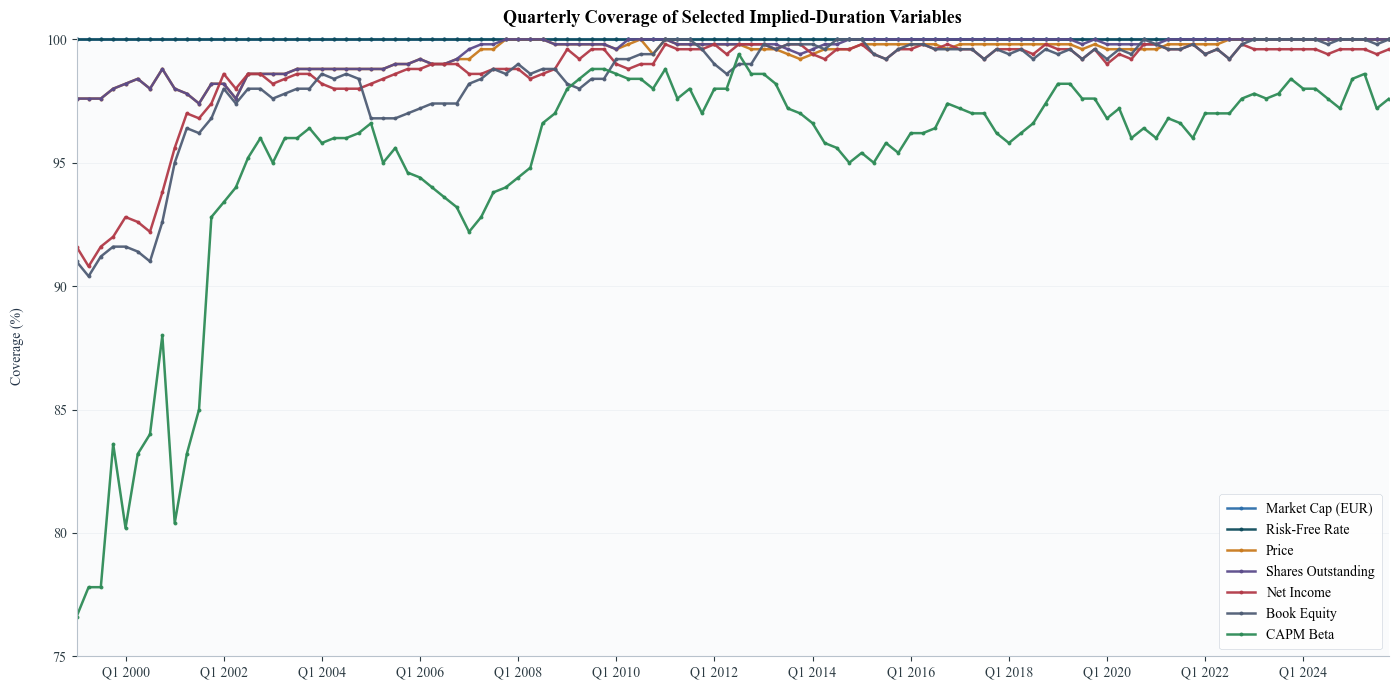

Saved coverage plot: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/implied_coverage_quarterly.png
Plotted labels: ['Market Cap (EUR)', 'Risk-Free Rate', 'Price', 'Shares Outstanding', 'Net Income', 'Book Equity', 'CAPM Beta']
Missing requested labels (not plotted): ['Market Return']
Label->column mapping: {'Market Cap (EUR)': 'mcap_eur', 'Risk-Free Rate': 'market_risk_free_rate_annual', 'Price': 'PriceClose', 'Shares Outstanding': 'shares_outstanding', 'Net Income': 'Net_Income', 'Book Equity': 'Book_Equity', 'CAPM Beta': 'beta'}


In [5]:
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure as _ps_save_figure

set_global_plot_style()

NOTEBOOK_GRAPH_DIR = BASE_DIR / "graphs" / "LSEG_DataPull_Implied"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 150):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=dpi)

IMPLIED_PATH = DATA_DIR / "euro500_implied.parquet"
if not IMPLIED_PATH.exists():
    raise FileNotFoundError(f"Missing file: {IMPLIED_PATH}")

imp = pd.read_parquet(IMPLIED_PATH).copy()
if "date" not in imp.columns:
    raise KeyError("'date' column missing in euro500_implied.parquet")

imp["date"] = pd.to_datetime(imp["date"], errors="coerce").dt.normalize()
imp = imp[imp["date"].notna()].copy()
imp["quarter"] = imp["date"].dt.to_period("Q").dt.start_time.dt.normalize()

# Exactly the requested coverage variables with robust source mapping.
requested_map = {
    "Price": ["PriceClose"],
    "CAPM Beta": ["beta", "Beta"],
    "Market Cap (EUR)": ["mcap_eur", "MarketCap", "market_cap"],
    "Net Income": ["Net_Income", "NetIncome", "net_income"],
    "Book Equity": ["Book_Equity", "BE", "book_equity"],
    "Market Return": ["r_m", "market_return_rate", "market_return_ffmcap_capped80", "market_return_ffmcap"],
    "Risk-Free Rate": ["r_f", "market_risk_free_rate_annual", "rf_estr_annual"],
    "Shares Outstanding": ["shares_outstanding"],
}

plot_spec = []
missing_labels = []
for label, candidates in requested_map.items():
    col = next((c for c in candidates if c in imp.columns), None)
    if col is None:
        missing_labels.append(label)
        continue
    plot_spec.append((label, col))

if not plot_spec:
    raise ValueError(
        "None of the requested columns are available in euro500_implied.parquet. "
        f"Requested labels: {list(requested_map.keys())}"
    )

calc_cols = [col for _, col in plot_spec]
coverage_plot_df = (
    imp.groupby("quarter")[calc_cols]
    .apply(lambda g: g.notna().mean() * 100.0)
    .reset_index()
)
coverage_plot_df = coverage_plot_df.sort_values("quarter").reset_index(drop=True)

# Plot starts at Q1 1999 (as in plot_style convention).
coverage_plot_df = coverage_plot_df[coverage_plot_df["quarter"] >= pd.Timestamp("1999-01-01")].copy()
if coverage_plot_df.empty:
    raise ValueError("No quarterly coverage data available from Q1 1999 onward.")

# Legend order by coverage level at Q1 1999 (fallback: first available quarter).
ref_quarter = pd.Timestamp("1999-01-01")
if (coverage_plot_df["quarter"] == ref_quarter).any():
    ref_row = coverage_plot_df.loc[coverage_plot_df["quarter"] == ref_quarter].iloc[0]
else:
    ref_row = coverage_plot_df.iloc[0]

plot_spec = sorted(
    plot_spec,
    key=lambda x: ref_row.get(x[1], float("nan")),
    reverse=True,
)

line_colors = [
    COLORS["blue"],
    COLORS["primary"],
    COLORS["orange"],
    COLORS["purple"],
    COLORS["accent"],
    COLORS["neutral"],
    COLORS["green"],
    COLORS["brown"],
]

fig, ax = plt.subplots(figsize=(14, 7))
for i, (label, col) in enumerate(plot_spec):
    color = line_colors[i % len(line_colors)]
    ax.plot(
        coverage_plot_df["quarter"],
        coverage_plot_df[col],
        label=label,
        color=color,
        linewidth=1.8,
        marker="o",
        markersize=2.8,
        markeredgewidth=0.0,
        alpha=0.95,
    )

ax.set_title("Quarterly Coverage of Selected Implied-Duration Variables")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(75, 100.1)

style_axes(ax, grid_axis="y", grid_alpha=0.3)
style_time_axis(
    ax,
    x_min=coverage_plot_df["quarter"].min(),
    x_max=coverage_plot_df["quarter"].max(),
    x_ticks=coverage_plot_df["quarter"],
    date_fmt="%Y",
)

# X-axis ticks: Q1 of even years only (Q1 2000, Q1 2002, ...).
q1_even_ticks = coverage_plot_df.loc[
    (coverage_plot_df["quarter"].dt.quarter == 1)
    & (coverage_plot_df["quarter"].dt.year % 2 == 0),
    "quarter",
]
if not q1_even_ticks.empty:
    ax.set_xticks(q1_even_ticks)
    ax.set_xticklabels([f"Q1 {d.year}" for d in q1_even_ticks], rotation=0)
style_legend(ax, loc="lower right", title=None)

graphs_dir = BASE_DIR / "graphs"
graphs_dir.mkdir(parents=True, exist_ok=True)
coverage_plot_path = graphs_dir / "implied_coverage_quarterly.png"

fig.tight_layout()
save_figure(fig, "implied_coverage_quarterly", dpi=220)
plt.show()

print("Saved coverage plot: implied_coverage_quarterly.png")
print("Plotted labels:", [label for label, _ in plot_spec])
if missing_labels:
    print("Missing requested labels (not plotted):", missing_labels)
print("Label->column mapping:", {label: col for label, col in plot_spec})
